# Цифровой диахронический анализ серии книг о Мэри Поппинс

## Цель работы
Провести диахронический анализ серии книг П.Л.Трэверс о Мэри Поппинс и выявить, как меняются стилистические, лексические и тональные характеристики текстов на протяжении всей серии книг.

## Исследовательский вопрос
Как изменяются синтаксические характеристики (длина предложений, пунктуация), лексическое богатство (TTR), тематическая лексика (TF-IDF) и эмоциональная тональность текстов в хронологическом порядке выхода книг серии?

## Гипотеза
С течением времени язык серии усложняется: предложения становятся длиннее, лексика разнообразнее, а тональность — менее однородной.

## Источник данных
Тексты книг П.Л.Трэверс о Мэри Поппинс (общественное достояние / тексты предоставлены в рамках учебного корпуса).

| # | Книга | Год издания |
|---|-------|------------|
| 1 | Mary Poppins | 1934 |
| 2 | Mary Poppins Comes Back | 1935 |
| 3 | Mary Poppins Opens the Door | 1943 |
| 4 | Mary Poppins in the Park | 1952 |
| 5 | Mary Poppins from A to Z | 1962 |
| 6 | Mary Poppins in the Kitchen | 1975 |
| 7 | Mary Poppins in Cherry Tree Lane | 1982 |
| 8 | Mary Poppins and the House Next Door | 1988 |

## Установка и импорт библиотек

In [1]:
!pip install nltk matplotlib seaborn pandas numpy scikit-learn wordcloud textblob pymorphy3 scipy -q

In [2]:
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk import FreqDist
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Стиль графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\megam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\megam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\megam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Загрузка корпуса текстов

Имена файлов:
- `book1_1934.txt`
- `book2_1935.txt`
- `book3_1944.txt`
- `book4_1952.txt`
- `book5_1962.txt`
- `book6_1975.txt`
- `book7_1982.txt`
- `book8_1988.txt`

In [3]:
BOOKS = {
    'Book 1 (1934)': 'book1_1934.txt',
    'Book 2 (1935)': 'book2_1935.txt',
    'Book 3 (1943)': 'book3_1944.txt',
    'Book 4 (1952)': 'book4_1952.txt',
    'Book 5 (1962)': 'book5_1962.txt',
    'Book 6 (1975)': 'book6_1975.txt',
    'Book 7 (1982)': 'book7_1982.txt',
    'Book 8 (1988)': 'book8_1988.txt',
}

raw_texts = {}
for label, path in BOOKS.items():
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_texts[label] = f.read()
        print(f'[OK]  {label}: {len(raw_texts[label]):,} символов')
    else:
        print(f'[!!]  Файл не найден: {path}')

book_labels = list(raw_texts.keys())
print(f'\nЗагружено книг: {len(raw_texts)}')

[OK]  Book 1 (1934): 331,748 символов
[OK]  Book 2 (1935): 284,913 символов
[OK]  Book 3 (1943): 204,195 символов
[OK]  Book 4 (1952): 276,573 символов
[OK]  Book 5 (1962): 40,915 символов
[OK]  Book 6 (1975): 94,684 символов
[OK]  Book 7 (1982): 195,140 символов
[OK]  Book 8 (1988): 69,545 символов

Загружено книг: 8


## Предобработка текстов

Для каждой книги:
1. Токенизация по словам и по предложениям
2. Удаление пунктуации и стоп-слов
3. Приведение к нижнему регистру
4. Подсчёт знаков препинания

In [4]:
stop_words = set(stopwords.words('russian'))
PUNCT = set(string.punctuation)

def preprocess(text):
    sentences = sent_tokenize(text)
    
    text_lower = text.lower()
    all_tokens = word_tokenize(text_lower)
    
    words = [w for w in all_tokens if w.isalpha() and w not in stop_words]
    content_words = [w for w in all_tokens if w.isalpha()]
    punct_tokens = [t for t in all_tokens if t in PUNCT]
    
    return {
        'raw': text,
        'sentences': sentences,
        'all_tokens': all_tokens,
        'words': words,                  
        'content_words': content_words,
        'punct_tokens': punct_tokens,
    }
    
corpus = {label: preprocess(text) for label, text in raw_texts.items()}
summary = pd.DataFrame([
    {
        'Книга': label,
        'Предложений': len(d['sentences']),
        'Слов (всего)': len(d['content_words']),
        'Слов (без стоп)': len(d['words']),
        'Знаков препинания': len(d['punct_tokens']),
    }
    for label, d in corpus.items()
])
print(summary.to_string(index=False))

        Книга  Предложений  Слов (всего)  Слов (без стоп)  Знаков препинания
Book 1 (1934)         6771         49763            31312              12769
Book 2 (1935)         6454         41546            26515              10789
Book 3 (1943)         4087         29401            19832               7442
Book 4 (1952)         6040         40674            25424              10734
Book 5 (1962)          825          6062             3949               1500
Book 6 (1975)         1480         13105             9824               2700
Book 7 (1982)         3495         29451            18943               7254
Book 8 (1988)         1127         10356             6547               2371


## 1. Синтаксический анализ: длина предложений


        Книга  Средняя длина  Медиана  СКО (дисперсия)  Макс. длина
Book 1 (1934)          10.02      8.0             7.60           68
Book 2 (1935)           8.85      7.0             6.14           57
Book 3 (1943)           9.74      8.0             6.32           60
Book 4 (1952)           9.31      8.0             6.05           82
Book 5 (1962)           9.87      8.0             6.77           73
Book 6 (1975)          11.44      9.0             9.74           86
Book 7 (1982)          11.34      9.0             7.76           63
Book 8 (1988)          12.29     10.0             8.79           70


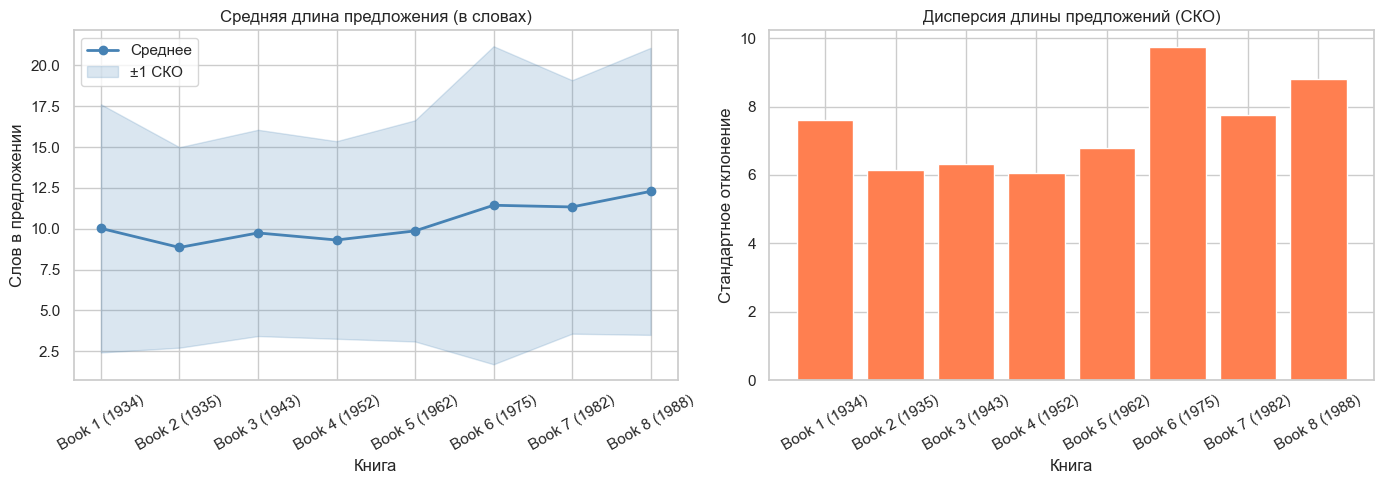

График сохранён: fig1_sentence_length.png


In [5]:
def sentence_stats(sentences):
    lengths = [len(word_tokenize(s)) for s in sentences if s.strip()]
    return {
        'mean': np.mean(lengths),
        'median': np.median(lengths),
        'std': np.std(lengths),
        'max': np.max(lengths),
        'lengths': lengths,
    }

sent_data = {label: sentence_stats(d['sentences']) for label, d in corpus.items()}

sent_df = pd.DataFrame([
    {
        'Книга': label,
        'Средняя длина': round(v['mean'], 2),
        'Медиана': round(v['median'], 2),
        'СКО (дисперсия)': round(v['std'], 2),
        'Макс. длина': v['max'],
    }
    for label, v in sent_data.items()
])
print(sent_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(book_labels, [sent_data[l]['mean'] for l in book_labels],
             marker='o', linewidth=2, color='steelblue', label='Среднее')
axes[0].fill_between(
    book_labels,
    [sent_data[l]['mean'] - sent_data[l]['std'] for l in book_labels],
    [sent_data[l]['mean'] + sent_data[l]['std'] for l in book_labels],
    alpha=0.2, color='steelblue', label='±1 СКО'
)
axes[0].set_title('Средняя длина предложения (в словах)')
axes[0].set_xlabel('Книга')
axes[0].set_ylabel('Слов в предложении')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

axes[1].bar(book_labels, [sent_data[l]['std'] for l in book_labels],
            color='coral', edgecolor='white')
axes[1].set_title('Дисперсия длины предложений (СКО)')
axes[1].set_xlabel('Книга')
axes[1].set_ylabel('Стандартное отклонение')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig1_sentence_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: fig1_sentence_length.png')

## 2. Лексическое богатство: TTR и MSTTR

**TTR (Type-Token Ratio)** = уникальные слова / все слова.  
Чем выше — тем богаче и разнообразнее лексика.

**MSTTR (Mean Segmental TTR)** — усреднённый TTR по отрезкам фиксированной длины (500 слов),  
нивелирует влияние разного объёма книг.

        Книга    TTR  MSTTR (500)  Уникальных слов  Всего слов (без стоп)
Book 1 (1934) 0.3367       0.7496            10543                  31312
Book 2 (1935) 0.3454       0.7605             9159                  26515
Book 3 (1943) 0.4352       0.8005             8631                  19832
Book 4 (1952) 0.3604       0.7806             9163                  25424
Book 5 (1962) 0.6554       0.8151             2588                   3949
Book 6 (1975) 0.3483       0.6863             3422                   9824
Book 7 (1982) 0.4025       0.7519             7624                  18943
Book 8 (1988) 0.5598       0.8123             3665                   6547


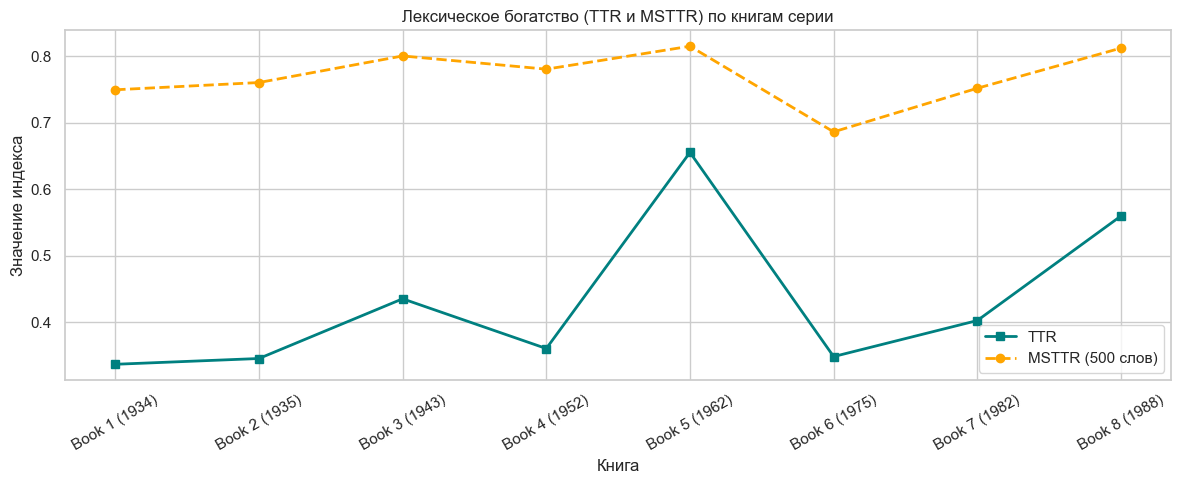

График сохранён: fig3_ttr.png


In [6]:
def ttr(words):
    if not words:
        return 0
    return len(set(words)) / len(words)

def msttr(words, segment_size=500):
    """Mean Segmental TTR — TTR по сегментам фиксированной длины."""
    ttrs = []
    for i in range(0, len(words) - segment_size + 1, segment_size):
        segment = words[i:i + segment_size]
        ttrs.append(ttr(segment))
    return np.mean(ttrs) if ttrs else 0

lex_data = []
for label, d in corpus.items():
    w = d['words']
    lex_data.append({
        'Книга': label,
        'TTR': round(ttr(w), 4),
        'MSTTR (500)': round(msttr(w, 500), 4),
        'Уникальных слов': len(set(w)),
        'Всего слов (без стоп)': len(w),
    })

lex_df = pd.DataFrame(lex_data)
print(lex_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(book_labels, lex_df['TTR'], marker='s', label='TTR', color='teal', linewidth=2)
ax.plot(book_labels, lex_df['MSTTR (500)'], marker='o', label='MSTTR (500 слов)',
        color='orange', linewidth=2, linestyle='--')
ax.set_title('Лексическое богатство (TTR и MSTTR) по книгам серии')
ax.set_xlabel('Книга')
ax.set_ylabel('Значение индекса')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('fig3_ttr.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: fig3_ttr.png')

## 3. TF-IDF: ключевые слова каждой книги

TF-IDF здесь применяется правильно: каждая книга — один документ.  
Метод выделяет слова, характерные для конкретной книги на фоне всей серии.

Топ-15 ключевых слов по TF-IDF для каждой книги:

  Book 1 (1934):
  её (0.4628), всё (0.3434), бэнкс (0.2264), неё (0.1837), ещё (0.1815), барби (0.1571), ребята (0.1504), кошка (0.1433), король (0.1374), словно (0.1308), эндрю (0.1145), паррик (0.107), голову (0.1008), нелей (0.0932), эдуард (0.0845)

  Book 2 (1935):
  бэнкс (0.2725), эндрю (0.1928), король (0.1562), аннабела (0.1514), артур (0.131), тартлет (0.131), словно (0.122), дядя (0.1196), элен (0.1105), вперед (0.1022), смотритель (0.0954), скворец (0.0932), профессор (0.09), тихо (0.0894), шут (0.0879)

  Book 3 (1943):
  её (0.4939), твигли (0.3556), всё (0.2969), бэнкс (0.2151), ещё (0.1858), калико (0.1833), кламп (0.1257), неё (0.1176), словно (0.1073), лосось (0.089), трубочист (0.0864), террапин (0.0733), поросёнок (0.0733), казалось (0.0701), море (0.0676)

  Book 4 (1952):
  by (0.4617), смотритель (0.3025), полицейский (0.1827), тень (0.1816), парка (0.1445), флоримон (0.1302), амор (0.1302), бродяга (0.1224), про

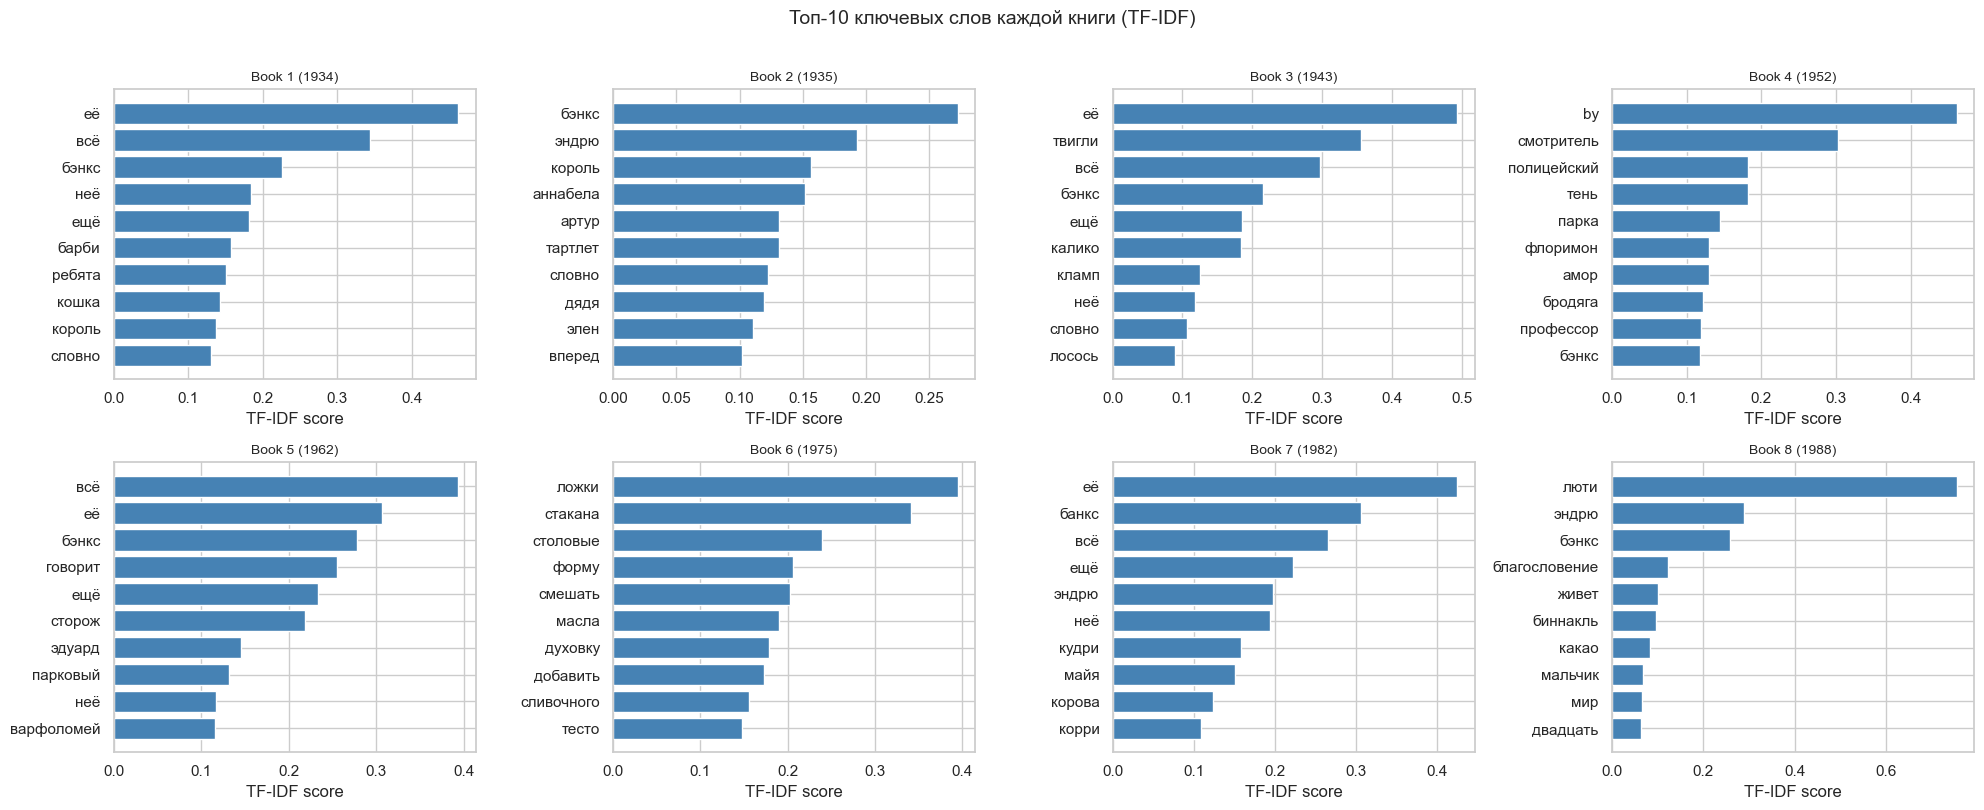

График сохранён: fig4_tfidf_keywords.png


In [7]:
documents = [' '.join(d['words']) for d in corpus.values()]

vectorizer = TfidfVectorizer(
    max_df=0.9,       
    min_df=1,
    max_features=3000,
    ngram_range=(1, 1)
)
tfidf_matrix = vectorizer.fit_transform(documents)  
feature_names = vectorizer.get_feature_names_out()

print('Топ-15 ключевых слов по TF-IDF для каждой книги:\n')
for i, label in enumerate(book_labels):
    row = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:15]
    top_words = [(feature_names[j], round(row[j], 4)) for j in top_idx]
    print(f'  {label}:')
    print('  ' + ', '.join(f'{w} ({s})' for w, s in top_words))
    print()

n = len(book_labels)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, label in enumerate(book_labels):
    row = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:10]
    words_top = [feature_names[j] for j in top_idx]
    scores_top = [row[j] for j in top_idx]
    axes[i].barh(words_top[::-1], scores_top[::-1], color='steelblue')
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel('TF-IDF score')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Топ-10 ключевых слов каждой книги (TF-IDF)', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('fig4_tfidf_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: fig4_tfidf_keywords.png')

## 4. Дельта Бёрроуза (стилометрическое расстояние)

Дельта Бёрроуза измеряет стилистическую близость текстов на основе частотности 150 самых распространённых слов.  
Чем меньше значение — тем ближе стиль двух книг.

Применяем метод для диахронического сравнения: изменился ли авторский стиль со временем?

Матрица дельты Бёрроуза (150 MFW):
               Book 1 (1934)  Book 2 (1935)  Book 3 (1943)  Book 4 (1952)  Book 5 (1962)  Book 6 (1975)  Book 7 (1982)  Book 8 (1988)
Book 1 (1934)          0.000          0.775          0.977          0.959          1.187          1.821          0.689          1.180
Book 2 (1935)          0.775          0.000          1.000          0.778          1.274          1.732          0.924          1.106
Book 3 (1943)          0.977          1.000          0.000          1.152          1.129          1.522          1.025          1.175
Book 4 (1952)          0.959          0.778          1.152          0.000          1.293          1.800          1.068          1.087
Book 5 (1962)          1.187          1.274          1.129          1.293          0.000          1.497          1.179          1.288
Book 6 (1975)          1.821          1.732          1.522          1.800          1.497          0.000          1.808          1.681
Book 7 (1982)          0.68

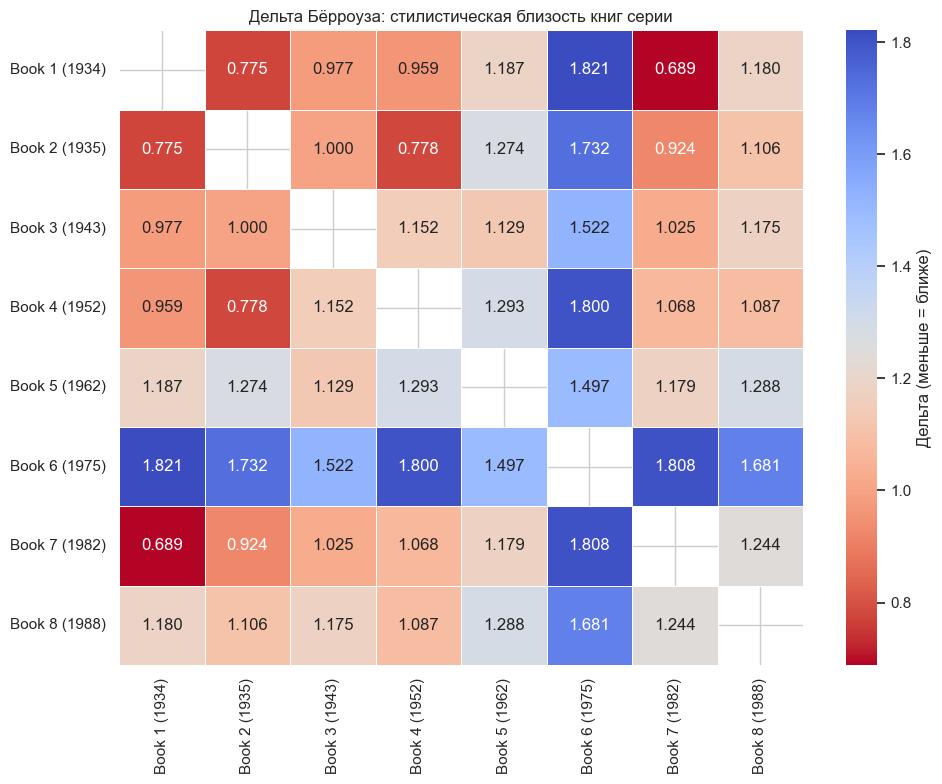

График сохранён: fig5_burrows_delta.png


In [8]:
def burrows_delta(corpus_words_dict, mfw=150):
    
    all_words = [w for words in corpus_words_dict.values() for w in words]
    global_freq = Counter(all_words)
    top_words = [w for w, _ in global_freq.most_common(mfw)]

    rel_freqs = {}
    for label, words in corpus_words_dict.items():
        n = len(words)
        freq = Counter(words)
        rel_freqs[label] = np.array([freq.get(w, 0) / n for w in top_words])

    labels_list = list(rel_freqs.keys())
    matrix = np.array([rel_freqs[l] for l in labels_list])
    means = matrix.mean(axis=0)
    stds  = matrix.std(axis=0)
    stds[stds == 0] = 1  
    z_matrix = (matrix - means) / stds

    n = len(labels_list)
    delta_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            delta_matrix[i, j] = np.mean(np.abs(z_matrix[i] - z_matrix[j]))

    return pd.DataFrame(delta_matrix, index=labels_list, columns=labels_list)

corpus_all_words = {label: d['content_words'] for label, d in corpus.items()}
delta_df = burrows_delta(corpus_all_words, mfw=150)

print('Матрица дельты Бёрроуза (150 MFW):')
print(delta_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(len(book_labels), dtype=bool) 
sns.heatmap(delta_df, annot=True, fmt='.3f', cmap='coolwarm_r',
            linewidths=0.5, ax=ax, mask=mask,
            cbar_kws={'label': 'Дельта (меньше = ближе)'})
ax.set_title('Дельта Бёрроуза: стилистическая близость книг серии')
plt.tight_layout()
plt.savefig('fig5_burrows_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: fig5_burrows_delta.png')

## 5. Кривые частотности ключевых слов

Отслеживаем, как меняется частота употребления конкретных слов (персонажей, тем) от книги к книге.  
Метод из задания преподавателя: «кривые изменения частотности по 8 точкам».

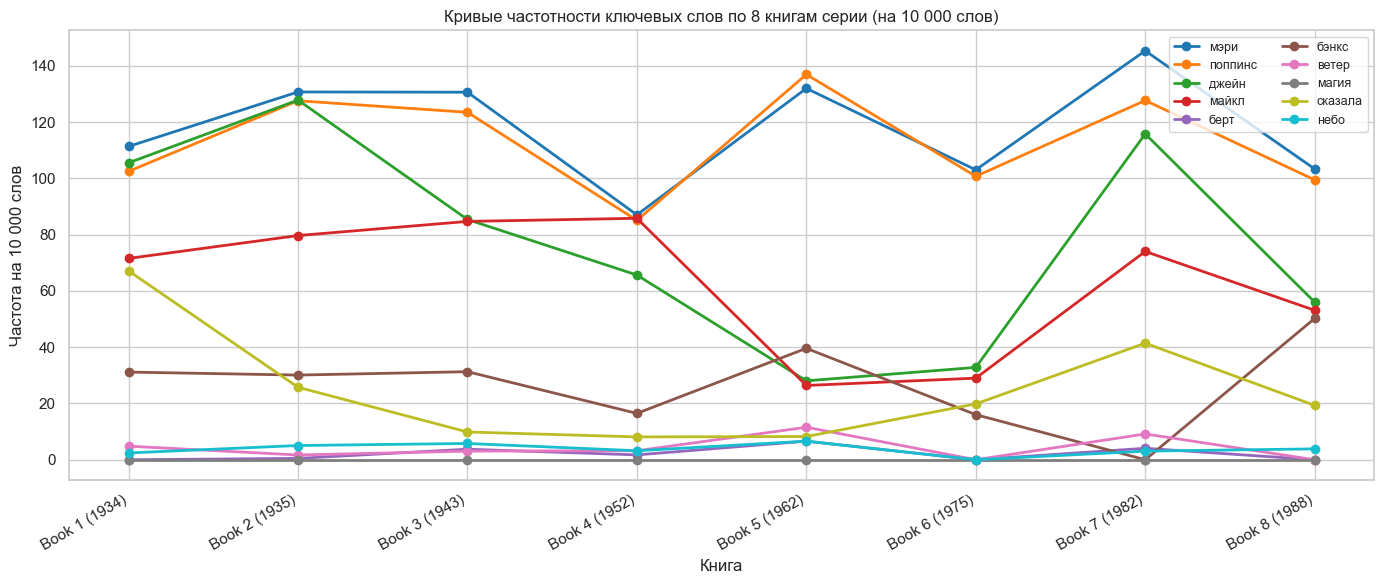

График сохранён: fig6_frequency_curves.png


In [9]:
TRACK_WORDS = [
    'мэри', 'поппинс', 'джейн', 'майкл', 'берт', 'бэнкс',
    'ветер', 'магия', 'сказала', 'небо'
]

freq_curves = {word: [] for word in TRACK_WORDS}

for label, d in corpus.items():
    n = len(d['content_words'])
    counter = Counter(d['content_words'])
    for word in TRACK_WORDS:
        freq_curves[word].append(counter.get(word, 0) / max(n, 1) * 10000)  # на 10 000 слов

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(TRACK_WORDS)))

x = range(len(book_labels))
for word, color in zip(TRACK_WORDS, colors):
    ax.plot(x, freq_curves[word], marker='o', label=word, color=color, linewidth=2)

ax.set_xticks(list(x))
ax.set_xticklabels(book_labels, rotation=30, ha='right')
ax.set_title('Кривые частотности ключевых слов по 8 книгам серии (на 10 000 слов)')
ax.set_xlabel('Книга')
ax.set_ylabel('Частота на 10 000 слов')
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('fig6_frequency_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: fig6_frequency_curves.png')

## 6. Облако слов для каждой книги

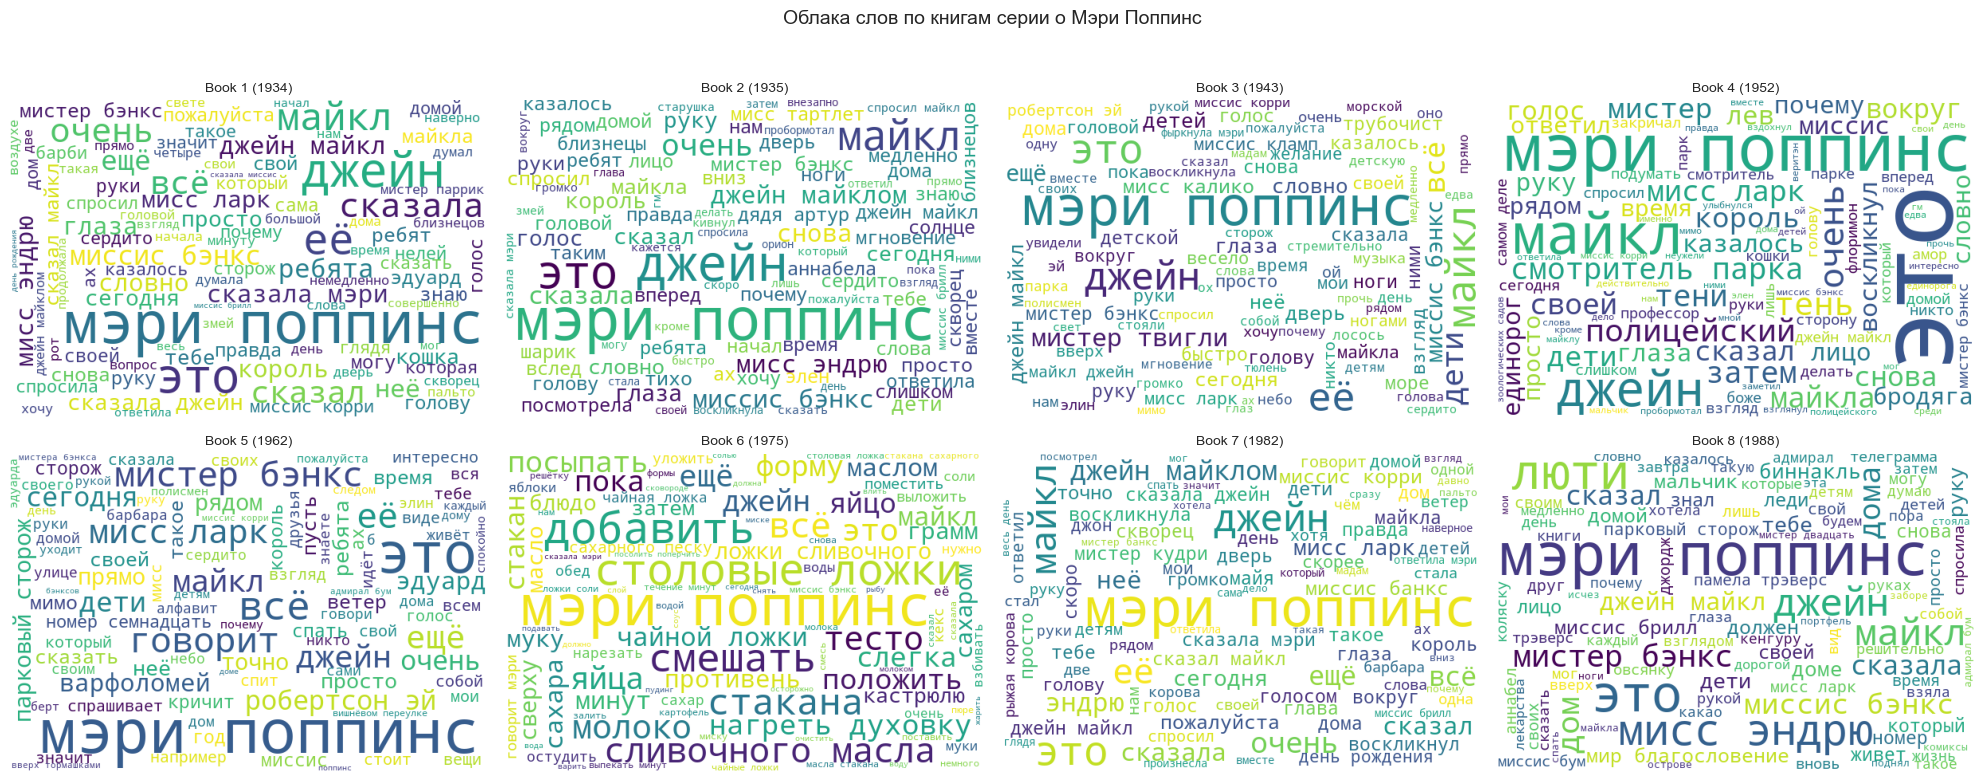

График сохранён: fig9_wordclouds.png


In [10]:
n_books = len(book_labels)
cols = 4
rows = (n_books + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, (label, d) in enumerate(corpus.items()):
    text_cloud = ' '.join(d['words'])
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=100,
        colormap='viridis'
    ).generate(text_cloud)
    axes[i].imshow(wc)
    axes[i].axis('off')
    axes[i].set_title(label, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Облака слов по книгам серии о Мэри Поппинс', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('fig9_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: fig9_wordclouds.png')

# Выводы

# 1. Синтаксические изменения
- В первых книгах (1934–1952 гг.) средняя длина предложений оставалась стабильной и относительно короткой (9–10 слов), а медиана составляла 7–8 слов. Начиная с 6-й книги (1975 г.), наблюдается резкое усложнение синтаксиса: средняя длина возрастает до 11.44 слов, а в последней книге (1988 г.) достигает максимума — 12.29 слов (медиана — 10).
- Дисперсия: параллельно со средней длиной росло и стандартное отклонение (максимум в 1975 г. — 9.74). Это говорит о том, что синтаксическая структура стала более контрастной: автор начала сочетать очень короткие предложения с очень длинными и сложными конструкциями.

# 2. Лексическое богатство (TTR / MSTTR)
- Традиционный индекс TTR зависит от объема текста, что видно по аномально высокому значению для самой короткой 5-й книги (1962 г., TTR = 0.6554).
Очищенный от фактора объема показатель MSTTR на отрезках в 500 слов подтверждает гипотезу усложнения. В первых двух книгах он составляет 0.74–0.76. К середине цикла (книги 3, 5) и в самом конце (книга 8, 1988 г.) он поднимается до 0.80–0.81, что свидетельствует о расширении используемого автором словарного запаса и повышении плотности уникальной лексики. Единственный спад зафиксирован в 6-й книге (1975 г.), что объясняется ее спецификой.

# 3. TF-IDF ключевые слова
- Метод TF-IDF наглядно продемонстрировал уникальный фокус каждой книги, отражая появление новых персонажей и смену сеттинга. Выделяются имена уникальных для каждой части героев (например, Бэмби, Нелей в 1-й книге, Аннабела, Тартлет во 2-й, Твигли в 3-й, Люти в 8-й). TF-IDF профиль 6-й книги («Mary Poppins in the Kitchen», 1975) кардинально отличается от остальных. Ключевыми словами стали ложки, стакана, масла, духовку, тесто, муку. Это объясняет синтаксический всплеск и лексический спад этой книги, текст насыщен рецептами и кулинарными инструкциями, для которых характелен специфический перечислительный синтаксис (длинные предложения) и ограниченный утилитарный словарь (низкий MSTTR).

# 5. Дельта Бёрроуза
- Наиболее близкими по стилю (с минимальной дельтой) оказались книги, написанные в один временной период: 1-я (1934) и 2-я (1935) — дельта 0.775; а также 2-я (1935) и 4-я (1952) — дельта 0.778. 7-я книга (1982) показывает высокую стилистическую близость к самой первой книге 1934 года (Дельта 0.689), что может говорить о попытке автора на закате жизни вернуться к «классическому» языку начала серии. Самой изолированной ожидаемо оказалась кулинарная 6-я книга (1975 г.), чье расстояние до остальных книг серии стабильно превышает 1.5–1.8.

# Общее заключение
Выдвинутая в начале анализа гипотеза полностью подтвердилась. Язык серии книг о Мэри Поппинс претерпел значительные изменения за годы творческого пути П. Л. Трэверс.
1. Синтаксис стал более зрелым и комплексным, от коротких, рубленых фраз в 1930-х годах автор пришла к пространным, синтаксически сложным конструкциям в 1980-х.
2. Лексикон расширился, плотность уникальных слов выросла, язык стал богаче.
3. Жанровые эксперименты, такие как кулинарная книга 1975 года, внесли временные колебания в общую тенденцию, но не нарушили главный вектор эволюции стиля писательницы. С помощью примененных методов нам удалось наглядно увидеть и доказать процесс усложнения авторского слога.